# 0. Carga de datos brutos

In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely import wkt
from google.cloud import bigquery
import unicodedata

import sys
import os
sys.path.append(os.path.abspath('..'))

from pre_procesado.linear_pipeline import build_linear_pipeline
from utils_entrenamiento import plot_shap_summary, evaluate_classification
from sklearn.linear_model import LogisticRegression

from pre_procesado.common_pipeline import run_global_pipeline
from utils_entrenamiento import walk_forward_split

import shap
from tqdm.auto import tqdm 

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [ ]:
client = bigquery.Client(project="project3grupo1")
query = """
WITH listings_dedup AS (
    SELECT *
    FROM `project3grupo1.airbnb_raw.listings`
    QUALIFY ROW_NUMBER() OVER (PARTITION BY id ORDER BY snapshot_date DESC) = 1
),

events_agg AS (
    SELECT 
        start_date,
        COUNTIF(category = 'sports') as num_sports,
        COUNTIF(category = 'festivals') as num_festivals,
        SUM(phq_attendance) as total_attendance
    FROM `project3grupo1.airbnb_features.events`
    GROUP BY start_date
),

holidays_valencia AS (
    SELECT DISTINCT date
    FROM `project3grupo1.airbnb_features.holidays`
    WHERE applies_to_valencia = True
),

calendar_dates AS (
    SELECT DISTINCT date
    FROM `project3grupo1.airbnb_raw.calendar`
),

days_to_holiday AS (
    SELECT
        cd.date,
        MIN(DATE_DIFF(h.date, cd.date, DAY)) as days_to_next_holiday
    FROM calendar_dates cd
    LEFT JOIN holidays_valencia h ON h.date >= cd.date
    GROUP BY cd.date
)

SELECT
    -- Identificadores añadidos
    c.listing_id,

    -- Target
    CASE WHEN c.available = False THEN 1 ELSE 0 END as is_occupied,

    -- Temporales
    c.date,
    EXTRACT(MONTH FROM c.date) as month,
    EXTRACT(DAYOFWEEK FROM c.date) as day_of_week,
    IF(EXTRACT(DAYOFWEEK FROM c.date) IN (1,7), 1, 0) as is_weekend,
    COALESCE(dh.days_to_next_holiday, 0) as days_to_next_holiday,
    IF(h.date IS NOT NULL, 1, 0) as is_holiday,

    -- Del piso
    l.neighbourhood_cleansed,
    l.room_type,
    l.accommodates,
    l.price as listing_price,
    l.minimum_nights,
    l.number_of_reviews,
    l.review_scores_rating,
    IF(l.number_of_reviews > 0, 1, 0) as has_reviews,
    l.instant_bookable,

    -- Meteorología
    w.temp_mean,
    w.precipitation_mm,

    -- Eventos
    COALESCE(e.num_sports, 0) as num_sports,
    COALESCE(e.num_festivals, 0) as num_festivals,
    COALESCE(e.total_attendance, 0) as total_attendance

FROM `project3grupo1.airbnb_raw.calendar` c
LEFT JOIN listings_dedup l ON c.listing_id = l.id
LEFT JOIN `project3grupo1.airbnb_features.weather` w ON c.date = w.date
LEFT JOIN events_agg e ON c.date = e.start_date
LEFT JOIN holidays_valencia h ON c.date = h.date
LEFT JOIN days_to_holiday dh ON c.date = dh.date
WHERE c.date <= '2026-05-19'
QUALIFY ROW_NUMBER() OVER (PARTITION BY c.listing_id, c.date ORDER BY c.date DESC) = 1
"""

df_raw = client.query(query).to_dataframe()
print(f"Datos brutos cargados desde BQ: {df_raw.shape}")

Datos brutos cargados desde BQ: (3376585, 22)


# 1. Instanciar pipeline y ejecución

In [ ]:
print("Iniciando Pipeline Global")
df_processed = run_global_pipeline(df_raw, max_lag=14)

print("\nGenerando particiones temporales")
folds = walk_forward_split(
    df_processed, 
    date_col='date', 
    n_folds=4,           # Prueba con 4 ventanas
    val_months=1,        # Predecir 1 mes al futuro
    min_train_months=8   # Entrenar al menos con 8 meses históricos
)

# primer fold para este experimento (Train vs Validación)
# Experimentos para encontrar las variables más relevantes -> acortamos el bucle
train_idx, val_idx = folds[0]

target = 'is_occupied'
#'listing_id'
metadata_cols = ['id_listing','date']

X_train_raw = df_processed.loc[train_idx].drop(columns=[target] + metadata_cols)
y_train = df_processed.loc[train_idx, target]

X_val_raw = df_processed.loc[val_idx].drop(columns=[target] + metadata_cols)
y_val = df_processed.loc[val_idx, target]

print(f"\n✅ Datos listos para inyectar en los Pipelines:")
print(f"   X_train: {X_train_raw.shape} | X_val: {X_val_raw.shape}")

Iniciando Pipeline Global
🔧 PIPELINE GLOBAL (FASE 1)
[Duplicados] Eliminadas 0 filas (0.00%). Retenidas: 3376585
[MNAR Flags] Creadas 1 variables indicadoras: ['is_missing_review_scores_rating']
[Lags Individuales] Creados 13 lags (2 a 14) sobre 'is_occupied' agrupados por listing_id.
[Rachas] Creadas 'streak_occupied' y 'streak_vacant' con shift(2).
[Barrio Features] Creadas: 'occ_barrio_ayer', 'occ_barrio_ma7', 'price_ratio_barrio'.
[Cíclicas] Creadas 'day_sin' y 'day_cos' a partir de 'day_of_week'.
[Casteo] Variables residuales binarizadas y features numéricas casteadas a float64.

------------------------------------------------------------
✅ Pipeline Global completado.
   Filas: 3376585 -> 3376585 | Columnas nuevas: +21
   Shape final: (3376585, 43)

Generando particiones temporales
  Fold 1: Train [2025-06..2026-01] (2,051,101 rows) | Val [2026-02..2026-02] (343,644 rows)
  Fold 2: Train [2025-06..2026-02] (2,394,745 rows) | Val [2026-03..2026-03] (380,463 rows)
  Fold 3: Train [

# 2. Instanciar modelo lineal y entrenar

**1º "Kitchen Sink Approach" (Echar todo lo que tienes a la olla)**

**2º "Feature Pruning" en base a SHAP values**

In [18]:
print("\n Construyendo Pipeline Lineal")
prep_linear = build_linear_pipeline()

print("Entrenando preprocesador lineal")
prep_linear.fit(X_train_raw, y_train)
X_train_lin = prep_linear.transform(X_train_raw)

X_val_lin = prep_linear.transform(X_val_raw)


 Construyendo Pipeline Lineal
[Pipeline Lineal] Construido: Imputer -> TargetEncoder -> Winsorizer -> StandardScaler.
Entrenando preprocesador lineal


In [19]:
print("Entrenando LogisticRegression Baseline")
modelo_lr = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
modelo_lr.fit(X_train_lin, y_train)

Entrenando LogisticRegression Baseline


LogisticRegression(max_iter=1000, n_jobs=-1, random_state=42)

# 4. Resultados

In [20]:
y_prob_lr = modelo_lr.predict_proba(X_val_lin)[:, 1]
y_pred_lr = modelo_lr.predict(X_val_lin)

eval_lr = evaluate_classification(y_val, y_pred_lr, y_prob_lr, fold_name="Reg. Logística (Exp 1)")


📊 Métricas [Reg. Logística (Exp 1)]:
          accuracy: 0.9423
         precision: 0.9025
            recall: 0.8986
                f1: 0.9006
           roc_auc: 0.9823
     avg_precision: 0.9611
       brier_score: 0.0417


# 5. Feature importance


Generando SHAP
[SHAP] Calculando valores SHAP para 41 features (LogisticRegression)...


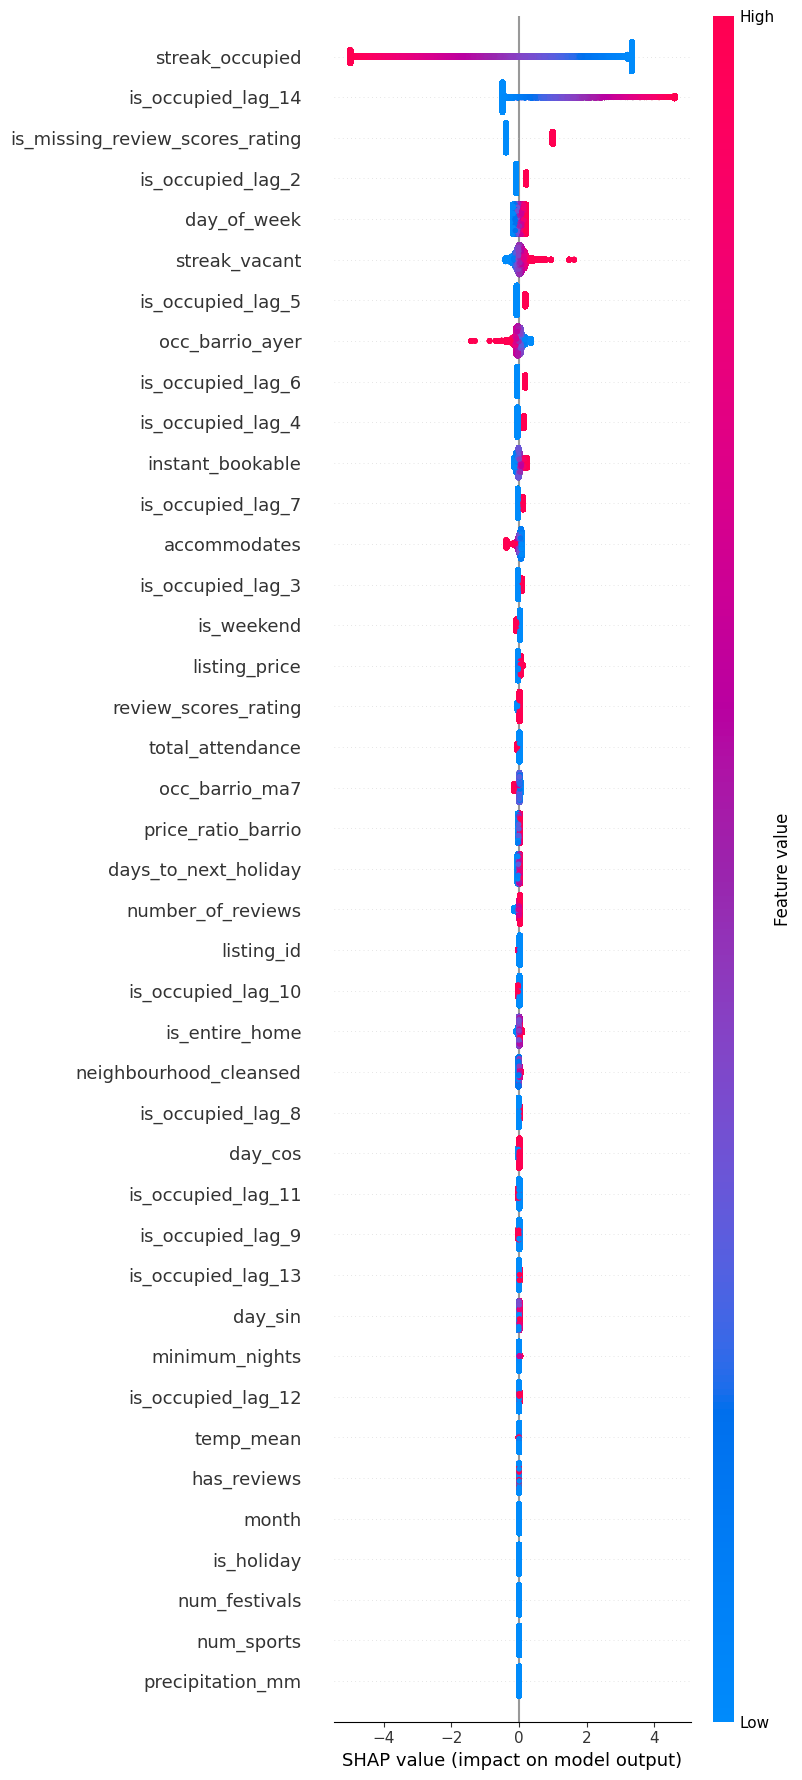

[SHAP] Summary plot generado para modelo: LogisticRegression


In [21]:
nombres_entrada = X_val_raw.columns.tolist()
try:
    columnas_finales = prep_linear.get_feature_names_out()
except:
    try:
        columnas_finales = prep_linear.named_steps['preprocessor'].get_feature_names_out()
    except:
        if isinstance(X_val_lin, pd.DataFrame):
            columnas_finales = X_val_lin.columns
        else:
            columnas_finales = nombres_entrada

columnas_limpias = [str(c).split('__')[-1] for c in columnas_finales]
if len(columnas_limpias) != X_val_lin.shape[1]:
    columnas_limpias = [f"Col_{i}" for i in range(X_val_lin.shape[1])]

# Crear DataFrame para el gráfico
X_val_df_plot = pd.DataFrame(X_val_lin, columns=columnas_limpias)

# 5. Graficar
print("\nGenerando SHAP")
plot_shap_summary(modelo_lr, X_val_df_plot, max_display=53)